# Pipeline: OPM-MEG & HD-fNIRS/DOT Multimodal Fusion via mSPoC

# Setup & Imports

In [ ]:
# Frameworks: Cedalion (v25.1.0+), MNE-Python, PyVista
# ==============================================================================

import os
import sys
import time
import warnings
from pathlib import Path
from tempfile import TemporaryDirectory

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import xarray as xr
from pint.errors import UnitStrippedWarning
from datetime import datetime

import cedalion
import cedalion.dataclasses as cdc
import cedalion.dot as dot
import cedalion.geometry.landmarks
import cedalion.io
import cedalion.math.resample as cd_resample
import cedalion.nirs
import cedalion.sigproc.motion_correct as motion
import cedalion.sigproc.quality as quality
import cedalion.vis.anatomy
import cedalion.vis.anatomy.sensitivity_matrix
import cedalion.vis.blocks as vbx
import cedalion.xrutils as xrutils
from cedalion import units
from cedalion.dot import TwoSurfaceHeadModel
from cedalion.io.forward_model import FluenceFile, load_Adot
from cedalion.sigproc.physio import global_component_subtract
from cedalion.vis.colors import mask_cmap, threshold_cmap
import mne
from mne.minimum_norm import apply_inverse_raw
from mne.minimum_norm import prepare_inverse_operator

SUBJECT = "voja"
MEAS_ID = "S3-2-finger"

# Forward modeling settings
FORWARD_MODEL = "NIRFASTER"  # Requires NIRFASTer installation
PRECOMPUTED_FLUENCE = True

# Flags
INTERACTIVE_PLOTS = True
MOTION_CORRECT = True
SHORT_COMPONENT_SUBTRACT = True
ADD_ANNOTATION = False

# Configure xarray and unit behavior
xrutils.unit_stripping_is_error()
xr.set_options(display_expand_data=False)

# Configure PyVista backend based on interactive flag
if INTERACTIVE_PLOTS:
    pv.set_jupyter_backend("server")
else:
    pv.set_jupyter_backend("static")


# Load fNIRS data 

In [ ]:
# Define base project directories (configurable relative to repository root)
DATA_DIR = Path("./data")
SUBJECT_DIR = DATA_DIR / "MRIsegmentation" / "example_head" / SUBJECT

# Paths for multimodal dataset and results
BASE_PATH = DATA_DIR / "measurements" / "multimodal"
NIRS_FOLDER = BASE_PATH / "fNIRS"
OUTPUT_DIR = BASE_PATH / MEAS_ID

# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define measurement files and quality control parameters
snirf_file = NIRS_FOLDER / f"{MEAS_ID}_.snirf"
bad_channels_visual = []

# Processing parameters
DOWNSAMPLE_FS = 5.0  # Target downsample frequency in Hz

# ------------------------------------------------------------------------------
# Read SNIRF File & Extract Metadata
# ------------------------------------------------------------------------------
print(f"Loading fNIRS data from: {snirf_file}")
rec = cedalion.io.read_snirf(str(snirf_file))[0]

# Extract optode montage and measurement list
montage = rec.geo3d
meas_list = rec._measurement_lists["amp"]

# Display raw signal attributes and sampling rate
display(rec["amp"])
original_sfreq = cedalion.sigproc.frequency.sampling_rate(rec["amp"]).magnitude
print(f"Original sampling frequency: {original_sfreq:.2f} Hz")


In [ ]:
# Check if all values in the 'value' column are equal to 1
if (rec.stim["value"] == 1).all():
    rec.stim["value"] = 2
    print("All values were 1. Replaced all with 2.")

rec.stim = rec.stim[rec.stim['value'] == 2].reset_index(drop=True) 
display(rec.stim[
    (rec.stim['value'] ==2)
].head(5))

# Load MEG data

In [ ]:

# Load MEG Data, Bad Channel/Epoch Mapping & Geometry

# Directory configurations (relative to repository data root)
SUBJECTS_DIR = DATA_DIR / "FreeSurferProject" / "subjects"
MEG_DIR = BASE_PATH / "MEG"
GEOMETRY_DIR = MEG_DIR / "mne_geometry"
EVENTS_DIR = MEG_DIR / "events"

# Set Freesurfer subjects directory in MNE environment
mne.utils.set_config("SUBJECTS_DIR", str(SUBJECTS_DIR), set_env=True)

# Define measurement-specific raw file
raw_fname = MEG_DIR / f"{MEAS_ID}-geom-raw.fif"
event_fname = EVENTS_DIR / f"{MEAS_ID}-meg-eve.txt"
annot_fname = OUTPUT_DIR / f"manual_rejections_{MEAS_ID}-annot.fif"

# ------------------------------------------------------------------------------
# Quality Control Mappings (Bad Channels & Epochs)
# ------------------------------------------------------------------------------
# Bad channel and epoch exclusions for current dataset (S3-2-finger)
bad_ch = ["X4", "Y4", "Z4", "X5", "Y5", "Z5", "X14", "Y14", "Z14", "X15", "Y15", "Z15", "X18", "Y18", "Z18"]
meg_bad_epochs = []

print(f"Applying bad channels for {MEAS_ID}: {bad_ch}")
print(f"Applying bad epochs for {MEAS_ID}: {meg_bad_epochs}")

# ------------------------------------------------------------------------------
# Read Raw Data, Events & MNE Forward Geometry
# ------------------------------------------------------------------------------
# Default identity transformation from MRI to Head space
trans = mne.transforms.Transform(fro="mri", to="head")

# Geometry file paths
src_fname = GEOMETRY_DIR / f"{SUBJECT}-oct6-src.fif"
bem_sol_fname = GEOMETRY_DIR / f"{SUBJECT}-5120-5120-5120-bem-sol.fif"

# Load raw continuous MEG data and stimulus events
print(f"Loading raw MEG: {raw_fname}")
raw = mne.io.read_raw_fif(raw_fname, preload=True)
events = mne.read_events(event_fname)

# Apply bad channel exclusion
raw.info["bads"] = bad_ch
raw.pick("meg", exclude="bads")

# Load anatomical forward modeling structures
bem_solution = mne.read_bem_solution(bem_sol_fname)
src = mne.read_source_spaces(src_fname)

## Clock Drift Assessment & Multimodal Time Alignment

Because OPM-MEG and HD-fNIRS data were recorded on independent hardware clocks, subtle clock drift can accumulate over time. In this dataset, a 40 s trial (20 s task / 20 s rest) measures as ~40.67 s on the fNIRS clock versus ~40.50 s on the MEG clock. Across a ~30-minute session, this introduces a ~6-second misalignment between modalities.

To ensure sample-accurate alignment across the entire recording, we treat the MEG system clock as the primary temporal reference and linearly warp the fNIRS time axis and stimulus timestamps to match the MEG event intervals.

In [ ]:
# ==============================================================================
# Multimodal Clock Alignment & Time Warping
# ==============================================================================

# Extract task-specific onsets (Trigger ID = 2)
task_stim_fnirs = rec.stim.loc[rec.stim["value"] == 2]
task_events_meg = events[events[:, 2] == 2]

n_epochs_fnirs = len(task_stim_fnirs)
n_epochs_meg = len(task_events_meg)
print(f"Detected Task Epochs — fNIRS: {n_epochs_fnirs} | MEG: {n_epochs_meg}")

# ------------------------------------------------------------------------------
# Compute Total Duration & Clock Drift Ratio
# ------------------------------------------------------------------------------
# fNIRS timing metrics
first_onset_fnirs = task_stim_fnirs["onset"].iloc[0]
last_onset_fnirs = task_stim_fnirs["onset"].iloc[-1]
total_duration_fnirs = last_onset_fnirs - first_onset_fnirs

fnirs_intervals = np.diff(rec.stim["onset"].values)
print(f"fNIRS First 5 Event Intervals (s): {np.round(fnirs_intervals[:5], 3)}")
print(f"fNIRS Total Span: {total_duration_fnirs:.3f} s")

# MEG timing metrics
sfreq_meg = raw.info["sfreq"]
first_onset_meg = task_events_meg[0, 0] / sfreq_meg
last_onset_meg = task_events_meg[n_epochs_fnirs - 1, 0] / sfreq_meg
total_duration_meg = last_onset_meg - first_onset_meg

meg_intervals = np.diff(task_events_meg[:, 0]) / sfreq_meg
print(f"MEG First 5 Event Intervals (s):   {np.round(meg_intervals[:5], 3)}")
print(f"MEG Total Span:   {total_duration_meg:.3f} s")

# Compute time scaling factor (ratio < 1.0 means fNIRS clock runs slower)
drift_ratio = total_duration_meg / total_duration_fnirs
print(f"Computed Drift Ratio (MEG / fNIRS): {drift_ratio:.7f}")

# Inspect sampling rate parameters
dt_fnirs = float(rec["amp"].time.values[1] - rec["amp"].time.values[0])
fs_fnirs = 1.0 / dt_fnirs
print(f"fNIRS Sampling Interval (dt): {dt_fnirs:.4f} s | Rate (fs): {fs_fnirs:.2f} Hz")

# ------------------------------------------------------------------------------
# Linear Time-Warping & Cropping
# ------------------------------------------------------------------------------
# Define crop boundaries with a 5-second buffer around first/last task events
t_min_crop = first_onset_meg - 5.0
t_max_crop = last_onset_meg + 5.0

# Shift and rescale all fNIRS timeseries coordinates
for key, da in rec.timeseries.items():
    # Warp time coordinates to match MEG clock
    corrected_time = ((da.time - first_onset_fnirs) * drift_ratio) + first_onset_meg
    da = da.assign_coords(time=corrected_time)
    
    # Crop to target window and restore unit attribute
    da = da.sel(time=slice(t_min_crop, t_max_crop))
    da.time.attrs["units"] = "s"
    rec.timeseries[key] = da

# Update stimulus dataframe timestamps and crop
rec.stim["onset"] = ((rec.stim["onset"] - first_onset_fnirs) * drift_ratio) + first_onset_meg
rec.stim["duration"] = 20.0

# Filter to keep only task events (value == 2) within the aligned buffer window
rec.stim = rec.stim.loc[
    (rec.stim["value"] == 2) & 
    (rec.stim["onset"] >= t_min_crop) & 
    (rec.stim["onset"] <= t_max_crop)
].reset_index(drop=True)

print("\n--- Synchronized Stimulus Table (Head) ---")
print(rec.stim.head())

In [ ]:
# Define output destination for cleaned stimulus timing table
stim_csv_path = OUTPUT_DIR / "stim_data.csv"

# Save aligned stimulus events to CSV
rec.stim.to_csv(stim_csv_path, index=False)
print(f"Synchronized stimulus schedule exported to: {stim_csv_path}")

# Load segmented MRI scan and generate head model


In [ ]:
# ==============================================================================
# Build Two-Surface Head Model (Voxel -> RAS Coordinate Frame)
# ==============================================================================

mask_files = {'csf': 'mask_csf.nii',
 'gm': 'mask_gray.nii',
 'scalp': 'mask_skin.nii',
 'skull': 'mask_bone.nii',
 'wm': 'mask_white.nii'}


head_ijk = TwoSurfaceHeadModel.from_surfaces(
    segmentation_dir= str(subject_dir),
    mask_files  = mask_files,
    brain_surface_file= subject_dir /"mask_brain.obj",
    scalp_surface_file= subject_dir / "mask_scalp.obj",
    landmarks_ras_file= subject_dir / "landmarks.mrk.json", 
    brain_seg_types=['gm', 'wm'],
    scalp_seg_types=['scalp'],
    smoothing=0.5,
    fill_holes=True,
    parcel_file= subject_dir / "parcels.json",
    brain_face_count=None,
    scalp_face_count=None
)
    
display(head_ijk)

# ------------------------------------------------------------------------------
# Transform Coordinates (Voxel IJK -> Scanner RAS)
# ------------------------------------------------------------------------------
# Extract transformation matrix to translate from voxel space to scanner RAS space
trafo = head_ijk.t_ijk2ras.rename({"aligned":"mni"})
head_ras = head_ijk.apply_transform(trafo)
display(head_ras)

TwoSurfaceHeadModel(
  crs: ijk
  tissue_types: csf, gm, scalp, skull, wm
  brain faces: 29996 vertices: 15002 units: dimensionless
  scalp faces: 23326 vertices: 11663 units: dimensionless
  landmarks: 5
)

TwoSurfaceHeadModel(
  crs: mni
  tissue_types: csf, gm, scalp, skull, wm
  brain faces: 29996 vertices: 15002 units: millimeter
  scalp faces: 23326 vertices: 11663 units: millimeter
  landmarks: 5
)

In [ ]:
# # Rename landmarks to match standard labels
landmark_label_map = {'nz': 'Nz', 'lpa': 'LPA', 'rpa': 'RPA', 'iz': 'Iz', 'cz': 'Cz'}
landmarks_renamed = [landmark_label_map.get(l.lower(), l) for l in head_ras.landmarks.label.values]
landmarks_renamed = head_ras.landmarks.assign_coords({'label': landmarks_renamed})
head_ras.landmarks = landmarks_renamed

# # Build 1010 system out of 4 fiducials
lmbuilder = cedalion.geometry.landmarks.LandmarksBuilder1010(head_ras.scalp, head_ras.landmarks)
landmarks_1010 = lmbuilder.build()
head_ras.landmarks = landmarks_1010

C:\Users\tappay01\Documents\cedalion\src\cedalion\geometry\landmarks.py:263: UserWarning: WIP: distance calculation around ears
  warnings.warn("WIP: distance calculation around ears")


### Optode Registration


In [ ]:
montage = rec.geo3d
labels = montage.label.values
print(f"{len(labels)} Available Labels: {labels}")

307 Available Labels: ['S0' 'S1' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7' 'S8' 'S9' 'S10' 'S11' 'S12' 'S13'
 'S14' 'D0' 'D1' 'D2' 'D3' 'D4' 'D5' 'D6' 'D7' 'D8' 'LPA' 'NASION' 'RPA'
 'HP_1' 'HP_2' 'HP_3' 'HP_4' 'HP_5' 'HP_6' 'HP_7' 'HP_8' 'HP_9' 'HP_10'
 'HP_11' 'HP_12' 'HP_13' 'HP_14' 'HP_15' 'HP_16' 'HP_17' 'HP_18' 'HP_19'
 'HP_20' 'HP_21' 'HP_22' 'HP_23' 'HP_24' 'HP_25' 'HP_26' 'HP_27' 'HP_28'
 'HP_29' 'HP_30' 'HP_31' 'HP_32' 'HP_33' 'HP_34' 'HP_35' 'HP_36' 'HP_37'
 'HP_38' 'HP_39' 'HP_40' 'HP_41' 'HP_42' 'HP_43' 'HP_44' 'HP_45' 'HP_46'
 'HP_47' 'HP_48' 'HP_49' 'HP_50' 'HP_51' 'HP_52' 'HP_53' 'HP_54' 'HP_55'
 'HP_56' 'HP_57' 'HP_58' 'HP_59' 'HP_60' 'HP_61' 'HP_62' 'HP_63' 'HP_64'
 'HP_65' 'HP_66' 'HP_67' 'HP_68' 'HP_69' 'HP_70' 'HP_71' 'HP_72' 'HP_73'
 'HP_74' 'HP_75' 'HP_76' 'HP_77' 'HP_78' 'HP_79' 'HP_80' 'HP_81' 'HP_82'
 'HP_83' 'HP_84' 'HP_85' 'HP_86' 'HP_87' 'HP_88' 'HP_89' 'HP_90' 'HP_91'
 'HP_92' 'HP_93' 'HP_94' 'HP_95' 'HP_96' 'HP_97' 'HP_98' 'HP_99' 'HP_100'
 'HP_101' 'HP_102' 'HP_103'

In [ ]:
keep_mask = [l for l in montage.label.values if 'S'==l[0] or 'D'==l[0] or 'HP'==l[:2]]
montage_reduced = montage.sel(label=keep_mask + ['LPA', 'NASION', 'RPA', 'Cz']) # need 4 points for align_and_snap_to_scalp
montage_reduced = montage_reduced.assign_coords({'label': [l.replace('NASION', 'Nz') for l in montage_reduced.label.values]})

#UnitStrippedWarning = warnings.filterwarnings("ignore", category=UnitStrippedWarning)
# Assign new values to Cz
montage_reduced.loc[dict(label='Cz')] =  [0.007  , -0.034,  0.074]*units.m  


In [ ]:
# Align montage to head model using fiducials and scalp points
geo3d_snapped = head_ras.align_and_snap_to_scalp(montage_reduced)

In [ ]:
import pyvista as pv
pv.set_jupyter_backend('server')
plt = pv.Plotter()
vbx.plot_surface(plt, head_ras.brain, color="w")
vbx.plot_surface(plt, head_ras.scalp, opacity=.3)
vbx.plot_labeled_points(plt, geo3d_snapped.pint.to('mm')) 
vbx.plot_labeled_points(
    plt, head_ras.landmarks.sel(label=["Nz", "Iz","LPA",'Cz', "RPA"]), show_labels=True,color="y"
    
)
plt.show()


In [ ]:
transform = head_ras.t_ras2ijk 
geo3d_snapped = geo3d_snapped.points.set_crs('aligned')
geo3d_snapped_ijk = geo3d_snapped.points.apply_transform(transform)
geo3d_snapped_ijk = geo3d_snapped_ijk.assign_coords(CRS='ijk') 

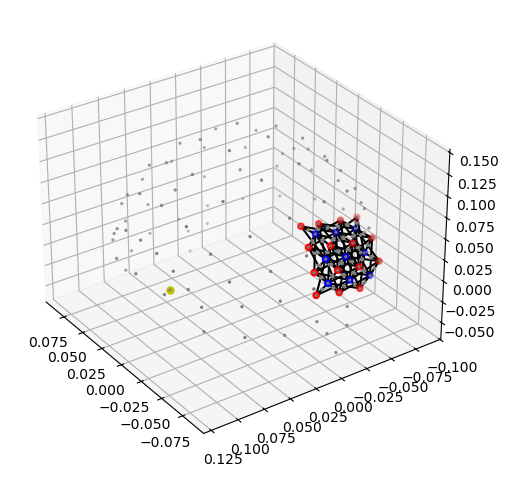

In [ ]:
# visualize the montage
rec.geo3d = rec.geo3d.points.rename({"LPA": "Lpa", "RPA": "Rpa","NASION": "Nz"})
rec.geo3d  =rec.geo3d.points.set_crs('aligned') # To really change the CRS
plotter =cedalion.vis.anatomy.plot_montage3D(rec["amp"], rec.geo3d )

# Preprocessing MEG

## Mark bad time window 

In [ ]:
#  Create the epochs object temporarily just to identify the time windows
epochs_tmp = mne.Epochs(raw, events, event_id=2, tmax=40, tmin=0, baseline=(0, 0), preload=True)
epochs_tmp.plot(n_epochs=20, block=True)  
# Update meg_bad_epochs here based on visual inspection of the epochs plot.
# Use the time spans of the bad epochs to mark raw
for idx in meg_bad_epochs:
    print(f"Marking epoch {idx} as BAD")
    # Get the start and end time of the specific bad epoch
    onset = epochs_tmp.events[idx, 0] / raw.info['sfreq'] 
    duration = 40
    
    # Add this as a BAD annotation to the original raw
    raw.annotations.append(onset, duration, description='BAD_manual1')


Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 30001 original time points ...
1 bad epochs dropped
Using qt as 2D backend.
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


## Denoising: Regressing via homogeneous field correction

Applied the homogeneous field correction (HFC) method to suppress environmental magnetic interference and improve data quality. 

https://mne.tools/stable/auto_tutorials/preprocessing/80_opm_processing.html

In [ ]:
print("Computing 1st-order Homogeneous Field Correction (HFC) projections...")
hfc_projs = mne.preprocessing.compute_proj_hfc(
    raw.info,
    order=1,
    picks="meg"
)

# Apply HFC projections in-place to the raw MEG recording
raw_hfc = raw.copy()
raw_hfc.add_proj(hfc_projs)
raw_hfc.apply_proj()

# Compute Power Spectral Density (PSD) post-denoising for quality check
psd_post_hfc = raw_hfc.compute_psd(
    fmax=20.0, 
    n_fft=int(np.round(raw_hfc.info["sfreq"]))
)

print("HFC denoising complete. Environmental interference suppressed.")

## Bandpass

In [ ]:
# notch filter
raw_hfc.notch_filter(50, notch_widths=4)
# bandpass filter
raw_hfc.filter(1, 40, n_jobs=6, fir_design='firwin', picks=['meg'])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 48 - 52 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 47.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 47.25 Hz)
- Upper passband edge: 52.50 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 52.75 Hz)
- Filter length: 4951 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done  36 out of  36 | elapsed:    1.0s finished


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 2475 samples (3.300 s)



[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed:   11.4s
[Parallel(n_jobs=6)]: Done  36 out of  36 | elapsed:   12.0s finished


<Raw | S3-2-ball-geom-raw.fif, 36 x 1208704 (1611.6 s), ~332.0 MiB, data loaded>

# Downsample

In [ ]:
# Preprocessing: Downsample from 500Hz to 100 Hz 
current_meg_fs = 100
raw_resampled = raw_hfc.resample(sfreq=current_meg_fs)

## ICA

In [ ]:
raw_for_ica = raw_resampled.copy()
# raw_for_ica.pick_channels(ch_names_rad)
# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=25, random_state=0,
                            max_iter="auto")
ica.fit(raw_for_ica)
ica.plot_sources(raw_for_ica, block=True)


Fitting ICA to data using 36 channels (please be patient, this may take a while)
Omitting 11213 of 161161 (6.96%) samples, retaining 149948 (93.04%) samples.
    Applying projection operator with 3 vectors (pre-whitener computation)
    Applying projection operator with 3 vectors (pre-whitener application)
Selecting by number: 25 components
    Applying projection operator with 3 vectors (pre-whitener application)
Fitting ICA took 3.6s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,36 iterations on raw data (149948 samples)
ICA components,25
Available PCA components,36
Channel types,mag
ICA components marked for exclusion,—


In [ ]:
ica.exclude = [7] # specify the indices of the ICA components to exclude (e.g., [0, 1, 2])
raw_cleaned = ica.apply(raw_for_ica.copy())

Applying ICA to Raw instance
    Applying projection operator with 3 vectors (pre-whitener application)
    Transforming to ICA space (25 components)
    Zeroing out 1 ICA component
    Projecting back using 36 PCA components


# MEG Source Localization

Source space          : <SourceSpaces: [<surface (lh), n_vertices=155942, n_used=4098>, <surface (rh), n_vertices=155090, n_used=4098>] MRI (surface RAS) coords, subject 'voja', ~27.4 MiB>
MRI -> head transform : instance of Transform
Measurement data      : instance of Info
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations



Read 2 source spaces a total of 8196 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00

Read 36 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00
MEG coil definitions created in head coordinates.
Source spaces are now in head coordinates.

Employing the head->MRI coordinate transform with the BEM model.
BEM model instance of ConductorModel is now set up

Source spaces are in head coordinates.
Checking that the sources are inside the surface (will take a few...)
Checking surface interior status for 4098 points...
    Found  779/4098 points inside  an interior sphere o

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


    Found  0/ 0 points outside using solid angles
    Total 0/36 points inside the surface
Interior check completed in 165.1 ms

Composing the field computation matrix...
Computing MEG at 8196 source locations (free orientations)...

Finished.
Using up to 150 segments
Using data from preloaded Raw for 150 events and 20 original time points ...
0 bad epochs dropped
    Created an SSP operator (subspace dimension = 3)
    Setting small MAG eigenvalues to zero (without PCA)
Reducing data rank from 36 -> 32
Estimating covariance using SHRUNK
Done.
Number of samples used : 3000
[done]
Computing rank from covariance with rank=None
    Using tolerance 2.1e-14 (2.2e-16 eps * 36 dim * 2.7  max singular value)
    Estimated rank (mag): 32
    MAG: rank 32 computed from 36 data channels with 0 projectors


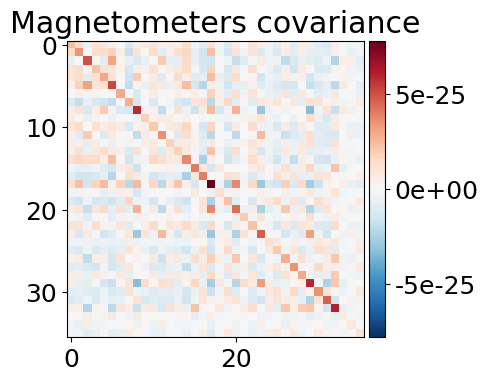

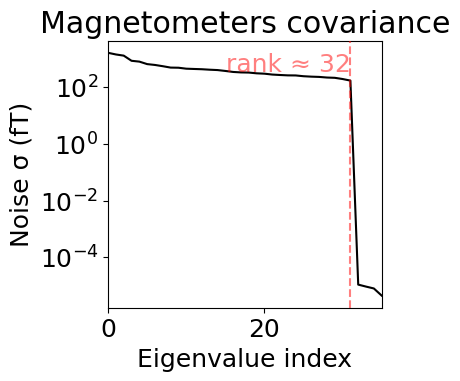

Converting forward solution to surface orientation
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 36 channels.
    36 out of 36 channels remain after picking
Selected 36 channels
Creating the depth weighting matrix...
    36 magnetometer or axial gradiometer channels
    limit = 4423/8196 = 10.000568
    scale = 2.93343e-10 exp = 1
Applying loose dipole orientations to surface source spaces: 0.2
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank=None
    Using tolerance 2.1e-14 (2.2e-16 eps * 36 dim * 2.7  max singular value)
    Estimated rank (mag): 32
    MAG: rank 32 computed from 36 data channels with 3 projectors
    Setting small MAG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whit

In [ ]:
# Compute the forward solution
# # Use the default M/EEG sensor positions from the raw file
fwd = mne.make_forward_solution(
    raw_cleaned.info,
    trans=trans, 
    src=src,
    bem=bem_solution,
    meg=True,
    eeg=False,
    n_jobs=1
)


# Compute noise covariance from the baseline period. 
noise_cov = mne.compute_raw_covariance(
    raw_cleaned,
    tmin=10, 
    tmax=40, # 
    method='shrunk',
    rank=None
)
# This shows if the noise covariance successfully "flattens" the noise
noise_cov.plot(raw_cleaned.info, exclude='bads')

# Compute the Inverse Operator (using dSPM as an example
inverse_operator = mne.minimum_norm.make_inverse_operator(
    raw_cleaned.info, 
    fwd, 
    noise_cov, 
    loose=0.2, 
    depth=True, 
    fixed= False #if loose > 0 
)

In [ ]:
# Created MNE Label objects
mne_labels = []  #list of MNE Labels created from the JSON (the dense labels)

# Parcel definitions JSON file path
parcels_json_fname = SUBJECT_DIR / "parcels.json"

with open(json_fname, 'r') as f:
    parcel_data = json.load(f)
    
for parcel in parcel_data:
    # Extract and force to a flat, sorted numpy array
    verts = np.unique(parcel['Vertices']).astype(int)
    
    # Skip if the parcel is empty to avoid the "one dimensional" error
    if verts.size == 0:
        print(f"Skipping empty parcel: {parcel['Label']}")
        continue

    # MNE Label requires hemisphere ('lh' or 'rh')
    hemi = 'lh' if parcel['Region'] == 'LH' else 'rh' 
    
    # Create the MNE Label object
    label = mne.Label(
        vertices=verts,
        name=parcel['Label'],
        hemi=hemi,
        subject=subject,
        color=parcel['Color'] 
    )
    mne_labels.append(label)

print(f"Created {len(mne_labels)} MNE Label objects.")

Created 601 MNE Label objects.


## Crop

In [ ]:
# Define temporal crop window around task bounds (5-second buffer)
# This creates a segment that is 5s before first events until last event

# NOTE: MNE's crop() re-indexes time coordinates so raw_cropped.times[0] == 0.0 s.
# Consequently, the first task event onset is shifted to exactly t = 5.0 s in this object.
raw_cropped = raw_cleaned.copy().crop(tmin=first_onset_meg - 5, tmax= last_onset_meg + 5) 


## Compute STC. Apply Inverse Solution

The goal is to have the final result only for the sensitive parcels. Use the label_names created earlier to keep only the data for those regions.

In [ ]:
# ==============================================================================
# Compute Source Estimate (STC) & Inverse Solution
# ==============================================================================

# File destination for cached STC output
stc_stem = OUTPUT_DIR / f"source_estimate_{MEAS_ID}"
stc_lh_fname = OUTPUT_DIR / f"source_estimate_{MEAS_ID}-lh.stc"

# Load cached source estimate if it exists, otherwise compute from raw
if stc_lh_fname.exists():
    print(f"Cached STC found: {stc_lh_fname.name}. Loading...")
    stc = mne.read_source_estimate(stc_lh_fname)
    print("Source estimate loaded successfully.")
else:
    print(f"No cached STC found. Computing inverse solution for {MEAS_ID}...")

    # Load and cast raw data array to float32 to optimize memory footprint
    raw_cropped.load_data()
    raw_cropped._data = raw_cropped._data.astype(np.float32)

    # Apply dSPM inverse operator to continuous raw MEG recording
    stc = apply_inverse_raw(
        raw=raw_cropped,
        inverse_operator=inverse_operator,
        lambda2=1.0 / 9.0,  # SNR = 3 -> lambda2 = 1/SNR^2
        method="dSPM",
        buffer_size=1000,
        pick_ori="normal",  # Extract normal surface orientation
    )

    # Save source estimate to disk
    stc.save(stc_stem, overwrite=True)
    print(f"Source estimate saved to: {stc_stem.name}")

File found: source_estimate_S3-2-ball-lh.stc. Loading...
SourceEstimate loaded successfully.


# Preprocessing fNIRS

### Identify short and long channel

The HD-fNIRS array over the left motor cortex comprises 15 sources and 9 detectors.
 - First nearest-neighbor channels (~1.5 cm distance) serve as short channels for extracerebral nuisance regression.
 - Second nearest-neighbor channels (~3.0 cm distance) serve as long channels sensitive to cortical hemodynamics.

In [ ]:
rec["ts_long"], rec["ts_short"] = cedalion.nirs.split_long_short_channels(rec["amp"], rec.geo3d,distance_threshold=1.8*units.cm)
display(rec["ts_long"])
long_channels = list(rec["ts_long"].coords["channel"].values)

Magnitude,[[[2.6088099479675293 2.6724331378936768 2.6354076862335205 ... 2.5475354194641113 2.5166678428649902 2.5555431842803955] [3.6124930381774902 3.6149351596832275 3.5756771564483643 ... 3.2244210243225098 3.2780001163482666 3.3243749141693115]] [[0.3998439908027649 0.4022834599018097 0.39500388503074646 ... 0.34562620520591736 0.3623712360858917 0.3824625611305237] [0.416404128074646 0.40287116169929504 0.4125913381576538 ... 0.3498897850513458 0.3469962477684021 0.3375352621078491]] [[2.453927516937256 2.4577691555023193 2.4735546112060547 ... 2.411672353744507 2.4217028617858887 2.4297282695770264] [6.039553642272949 6.039270401000977 6.069490909576416 ... 5.65900182723999 5.701322555541992 5.77536678314209]] ... [[1.5415929555892944 1.5401217937469482 1.5085928440093994 ... 1.5321919918060303 1.532463550567627 1.5394892692565918] [1.4198708534240723 1.427314281463623 1.4071497917175293 ... 1.3136409521102905 1.3345892429351807 1.356009602546692]] [[1.9072340726852417 1.8989989757537842 1.9226253032684326 ... 1.852839469909668 1.8939614295959473 1.8913934230804443] [1.5791001319885254 1.5750586986541748 1.5359559059143066 ... 1.4154785871505737 1.4472912549972534 1.4556443691253662]] [[0.5919192433357239 0.5988598465919495 0.5808585286140442 ... 0.5967378616333008 0.5916234850883484 0.6019521355628967] [0.6512338519096375 0.6490315794944763 0.6489564776420593 ... 0.5934522747993469 0.5906795263290405 0.5889952778816223]]]
Units,dimensionless


## Identify bad channels



### a) Visual inspection. 
Just in case this is given manually. For this subject is assumed to be all good.

### b) Channel Quality Metrics: SNR
Using a simple SNR threshold


In [ ]:
snr_thresh = 3 # the SNR (std/mean) of a channel.

# SNR thresholding using the "snr" function of the quality subpackage
_, snr_mask = quality.snr(rec["amp"], snr_thresh)

masks = [snr_mask]
# drop channels with bad signal quality (here we only need the list of channels):
_, snr_ch_droplist = quality.prune_ch(rec["amp"], masks, "all")

# list of bad channels
display(f"{len(snr_ch_droplist)} bad channels due to SNR. : {snr_ch_droplist}")


"7 bad channels due to SNR. : ['S6D8' 'S7D8' 'S9D8' 'S10D8' 'S11D8' 'S13D8' 'S14D8']"

In [ ]:
# Create a 1D mask (channel) .This is True only if BOTH wavelengths were True
common_mask_1d = snr_mask.all(dim='wavelength')
# Broadcast it back to (channel, wavelength)
common_snr_mask = snr_mask.copy(data=common_mask_1d.broadcast_like(snr_mask).values)
common_snr_mask


<xarray.DataArray (channel: 81, wavelength: 2)> Size: 162B
True True True True True True True True ... True True True True True False False
Coordinates:
  * channel     (channel) object 648B 'S0D0' 'S0D1' 'S0D3' ... 'S14D7' 'S14D8'
    source      (channel) object 648B 'S0' 'S0' 'S0' 'S1' ... 'S14' 'S14' 'S14'
    detector    (channel) object 648B 'D0' 'D1' 'D3' 'D0' ... 'D6' 'D7' 'D8'
  * wavelength  (wavelength) float64 16B 750.0 850.0

### c) Channel Quality Metrics:  SCI to percentage of time
SCI measures high-frequency cardiac signal coherence across wavelengths (> 0.5).




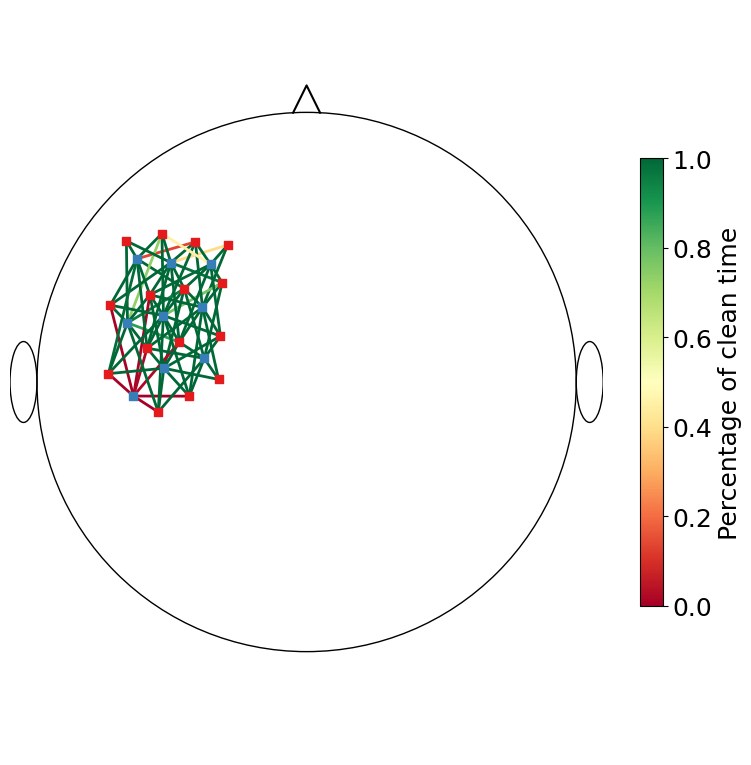

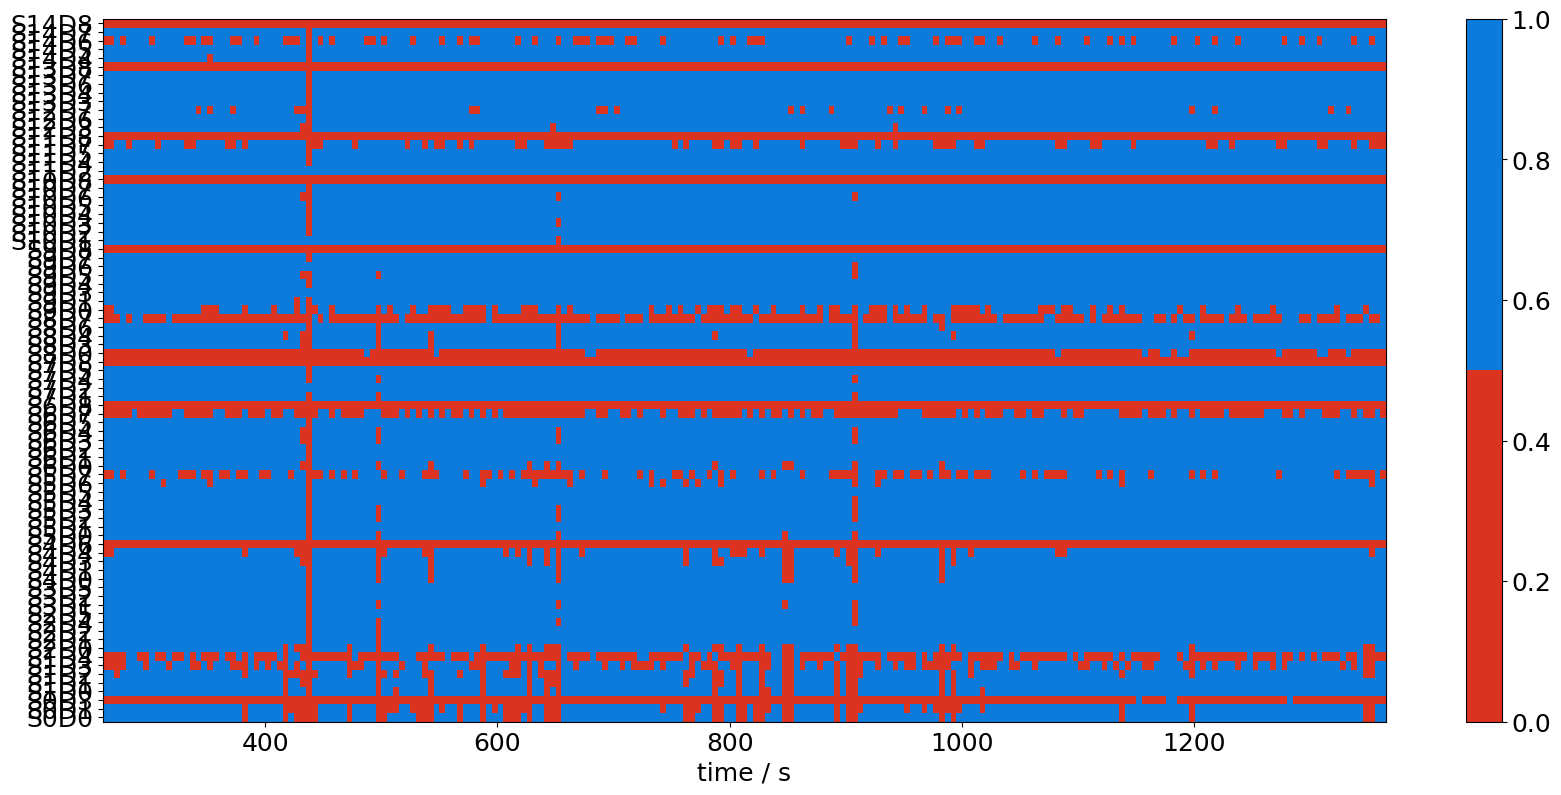

In [ ]:
# scalp coupling index (SCI) of the channels
sci_threshold = 0.5
window_length = 5*units.s
rec["amp"].time.attrs["units"] = "s"
sci, sci_mask = quality.sci(rec["amp"], window_length, sci_threshold)

perc_time_clean = sci_mask.sum(dim="time") / len(sci.time)

# plot the percentage of clean time per channel
f,ax = plt.subplots(1,1,figsize=(8,8))

cedalion.vis.anatomy.scalp_plot(
    rec["amp"],
    geo3d_snapped_ijk, 
    perc_time_clean,
    ax,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    title=None,
    cb_label="Percentage of clean time",
    channel_lw=2
)
f.tight_layout()

# plot this as a binary heatmap
f,ax = plt.subplots(1,1,figsize=(17,8))
sci_binary_norm, sci_binary_cmap = mask_cmap()
m = ax.pcolormesh(sci_mask.time, np.arange(len(sci_mask.channel)), sci_mask, shading="nearest", cmap=sci_binary_cmap)
cb = plt.colorbar(m, ax=ax)
plt.tight_layout()
ax.yaxis.set_ticks(np.arange(len(sci_mask.channel)))
ax.yaxis.set_ticklabels(sci_mask.channel.values);
ax.set_xlabel("time / s");


In [ ]:
# mask for percentage of time both metrics are above the thresholds.
perc_time_clean_2d = perc_time_clean.expand_dims(wavelength=[750, 850]).transpose("channel", "wavelength")
perc_time_clean_mask = perc_time_clean_2d > 0.8 

In [ ]:
# put all masks in a list
masks = [common_snr_mask, perc_time_clean_mask] 
# keep only channels that pass all criteria
rec["amp_masked"], ch_droplist = quality.prune_ch(rec["amp"], masks, "all", flag_drop = False) 

# list of excluded channels
display(f"{len(ch_droplist)} excluded channels. : {ch_droplist}")
good_long_ch = [ch for ch in long_channels if ch not in ch_droplist]

"12 excluded channels. : ['S0D3' 'S1D4' 'S4D6' 'S6D8' 'S7D8' 'S8D0' 'S8D7' 'S9D8' 'S10D8' 'S11D8'\n 'S13D8' 'S14D8']"

# Channel Space - OD

- Convert intensity raw amplitude to changes in Optical Density (OD).
- Apply Temporal Derivative Distribution Repair (TDDR) to remove motion baseline shifts.
- Apply a 0.01 - 0.5 Hz bandpass filter to remove low-frequency drift and high-frequency physiological noise.

In [ ]:
# Get optical densities
rec["od"] = cedalion.nirs.cw.int2od(rec["amp_masked"])
# Change the masked values in rec["od"] from NaN to 0
rec["od"] = rec["od"].fillna(0.0)

if motion_correct: #(optional)
        rec["od_tddr"] = motion.tddr(rec["od"]) # I am not sure if tddr is needed.
        rec["od_corrected"] = motion.wavelet(rec["od_tddr"])
        rec["od_filt"] = rec["od_corrected"].cd.freq_filter(
        fmin=0.01, fmax =0.5, butter_order= 4) 
else:
    rec["od_filt"] = rec["od"].cd.freq_filter(
    fmin=0.01, fmax =0.5, butter_order= 4) ### try change here

rec["od_filt"]

Magnitude,[[[-0.005690895775451521 -0.006761587161218408 -0.00782678755777545 ... 0.01900840266430823 0.017478542384369633 0.015930153263171667] [-0.011758057531497756 -0.01320409069697135 -0.014649041640646305 ... 0.023498504193622802 0.021448503972317238 0.01936744398384567]] [[-0.010719569563353251 -0.014882067955445458 -0.018991382101622288 ... 0.03531787201664589 0.032518408755451075 0.029683303212317564] [-0.02274266089580414 -0.02573148931543478 -0.02871936872428489 ... 0.053582320768087825 0.048998752142683615 0.044359236225968435]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] ... [[-0.016384222808228783 -0.016909095801216127 -0.017477749745294518 ... 0.02502170339626218 0.022630964697300165 0.020186698888910927] [-0.02842021637062507 -0.029468940343821616 -0.030560331879469126 ... 0.03862719900909413 0.03461017043454838 0.030487318970446656]] [[-0.0049141341733407945 -0.005540160262080931 -0.006165337100347699 ... 0.012405414799056444 0.011207717843682064 0.00998881910949501] [-0.010584959085185577 -0.011933502585810954 -0.013277733520702894 ... 0.022180761064087083 0.020007601520870305 0.017796049255024697]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]]]
Units,dimensionless


## Weighted Global Component Subtraction (Short channels regression)


In [ ]:
### Channel Space - Conc
dpf = xr.DataArray(
    [6, 6],
    dims="wavelength",
    coords={"wavelength": rec["amp"].wavelength},
)

rec["conc"] =  cedalion.nirs.cw.od2conc(rec["od_filt"], geo3d=rec.geo3d, dpf=dpf)


In [ ]:
# we use a large factor that will be multiplied with the channel variance to effectively remove the channel from the analysis wherever it is weighted by its variance
exclude_list = list(long_channels) + list(ch_droplist)
rel_var = 1e5 

conc_var = quality.measurement_variance(rec["conc"], exclude_list, rel_var)

# Weight of the long channels and bad channels are forced to be close to 0 because we want to get only short channels contribution to the noise template

# k=0 
if short_component_subtract:
    rec["conc_clean"], sc_comp  = global_component_subtract(ts=rec["conc"], ts_weights= 1 / conc_var, k=0)    
    # Difference (before – corrected)
    diff= rec["conc"] - rec["conc_clean"]
else:  
    rec["conc_clean"] = rec["conc"]


In [ ]:

rec["od_clean"] =  cedalion.nirs.cw.conc2od(rec["conc_clean"], geo3d=rec.geo3d, dpf=dpf)
rec["od_downsampled"] = cd_resample.resample(data=rec["od_clean"], Fs=downsample_fs)

# Image Reconstruction



## Light Propagation Simulation in Tissue (NIRFASTer Forward Model)
Compute photon fluence and sensitivity matrix (Adjoint Method / NIRFASTer) using the 3D head model and snapped optode geometry.

In [ ]:
fwm = dot.ForwardModel(head_ijk, geo3d_snapped_ijk, meas_list)

fluence_fname = OUTPUT_DIR / f"{SUBJECT}_fluence.h5"

fwm.compute_fluence_nirfaster(fluence_fname)
print(f"NIRFASTer simulation complete. Fluence saved to: {fluence_fname.name}")

In [ ]:
# for plotting use a geo3d without the landmarks
geo3d_plot_ras = geo3d_snapped[geo3d_snapped.type != cdc.PointType.LANDMARK] 
geo3d_plot_ijk = geo3d_snapped_ijk[geo3d_snapped_ijk.type != cdc.PointType.LANDMARK]

### Calculate the sensitivity matrices
The forward model's function `compute_sensitivity` calculates the sensitivity matrix from the fluence file and saves the result.

In [ ]:
sensitivity_fname = OUTPUT_DIR / f"{SUBJECT}_sensitivity.h5"

fwm.compute_sensitivity(fluence_fname, sensitivity_fname)
# load and display sensitivity matrix
Adot = load_Adot(sensitivity_fname)


### Plot Sensitivity Matrix

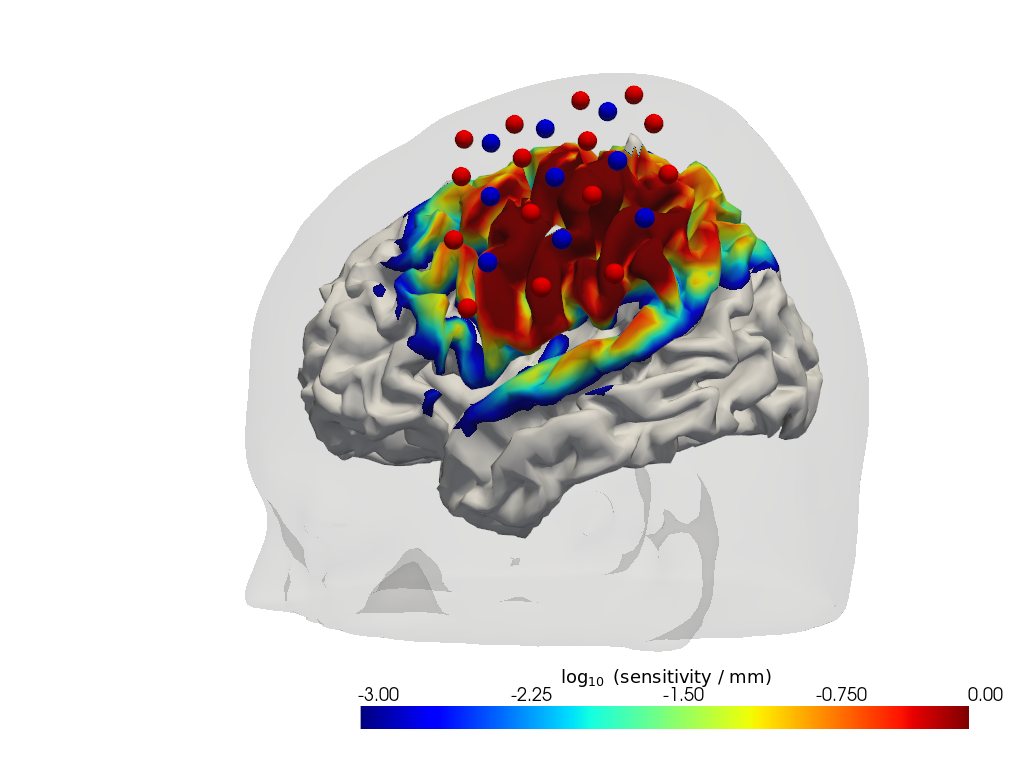

In [ ]:
pv.set_jupyter_backend('static') # or 'server' for interactive
    
plotter = cedalion.vis.anatomy.sensitivity_matrix.Main(
    sensitivity=Adot,
    brain_surface=head_ras.brain,
    head_surface=head_ras.scalp,
    labeled_points=geo3d_plot_ras,
    wavelength=750
    )
plotter.plot(high_th=0, low_th=-3)
left_view = [(-500, 0, 0), (0, 0, 0), (0, 0, 1)]
plotter.plt.show(cpos=left_view)

## Thresholding sensitivity of a probe to the cortex 

The anatomical brain surface is parcellated into ~600 discrete regions using the structural MRI segmentation pipeline (parcels.json). To reduce computational complexity and improve the signal-to-noise ratio during multimodal spatial filtering (mSPoC) and image reconstruction, we compute the total sensitivity of each parcel from the forward model matrix ($A_{\text{DOT}}$). Parcels whose integrated optical sensitivity falls below a designated threshold ($\text{dOD}_{\text{thresh}}$) are masked out, leaving only the cortical regions directly underlying the fNIRS optode array.

In [ ]:
# parcels data
parcels_json_fname = SUBJECT_DIR / "parcels.json"
parcels = cedalion.io.read_parcellations(parcels_json_fname)

# Define threshold for sensitive parcels
dOD_thresh = 0.001
minCh = 1
dHbO = 10  # µM
dHbR = -3  # µM

#UnitStrippedWarning = warnings.filterwarnings("ignore", category=UnitStrippedWarning) # ignore unit stripping warnings
parcel_dOD, parcel_mask = fwm.parcel_sensitivity(
    Adot, ch_droplist, dOD_thresh, minCh, dHbO, dHbR)

# fetch parcels from the parcel_mask that are above the threshold to a list of parcel names
sensitive_parcels_fnirs = parcel_mask.where(parcel_mask, drop=True)["parcel"].values.tolist()
dropped_parcels = parcel_mask.where(~parcel_mask, drop=True)["parcel"].values.tolist()
display(f"Number of sensitive parcels: {len(sensitive_parcels_fnirs)}")
display(f"Number of dropped parcels: {len(dropped_parcels)}")

'Number of sensitive parcels: 44'

'Number of dropped parcels: 555'

In [ ]:
# Mask the sensitivity matrix (Adot)
sensitive_parcel_names = parcel_mask.parcel.values[parcel_mask.values]
Adot_masked = Adot.sel(vertex=Adot.parcel.isin(sensitive_parcel_names))

In [ ]:
# Ensure dOD matches the channels in masked Adot
rec["od_downsampled"] = cd_resample.resample(data=rec["od_clean"], Fs=5)
rec["od_mask_ch"] = rec["od_downsampled"].sel(channel=Adot_masked.channel)

In [ ]:
recon = dot.ImageRecon(
    Adot_masked,
    recon_mode="mua2conc",
    brain_only=False,
    alpha_meas=0.01, 
    alpha_spatial=0.001,
    apply_c_meas=False, # optional: apply c_meas and change alpha_meas to 10?
    spatial_basis_functions=None,
)

In [ ]:
img = recon.reconstruct(rec["od_mask_ch"]) 
# Filter for brain vertices
img_brain = img.sel(vertex=img.is_brain)

# Baseline Subtraction. 
baseline_window = img_brain.copy().sel(time=slice(first_onset_meg - 1.0, first_onset_meg))
baseline = baseline_window.mean('time')

# Subtract the baseline from all time points. 
img_blsubtracted = img_brain - baseline

In [ ]:
# Average over parcels
HbO = img_blsubtracted.sel(chromo="HbO").groupby('parcel').mean()
HbR = img_blsubtracted.sel(chromo="HbR").groupby('parcel').mean()

HbO = HbO.transpose("time", "parcel")
HbR = HbR.transpose("time", "parcel")

fnirs_da = xr.concat([HbO, HbR], dim='chromo')

# Assign names to the new dimension
fnirs_da = fnirs_da.assign_coords(chromo=['HbO', 'HbR'])


## Align Labels to MEG Source Space & Intersect fNIRS Sensitive Parcels
1. Restrict dense anatomical labels (from surface mesh) to the sparse MEG 
source space ('src', e.g., oct-6 resolution) using `label.restrict(src)`.
2. Normalize hemisphere suffix naming differences between fNIRS parcellation 
('LABEL_LHH' / 'LABEL_RHH') and MNE labels ('LABEL_LH' / 'LABEL_RH').
3. Filter for joint MEG/fNIRS sensitive labels to restrict downstream mSPoC 
cross-modal analysis to overlapping regions of interest.

In [ ]:
def standardize_name(name):
    """Normalizes label names by removing extra trailing hemisphere characters (e.g., '_LHH' -> '_LH')."""
    return name.replace('_LHH', '').replace('_RHH', '').replace('_LH', '').replace('_RH', '')

# Quick lookup for fNIRS sensitive parcels
sens_dict = {standardize_name(n): n for n in sensitive_parcels_fnirs}

aligned_labels = []
not_aligned_labels = []

for label in mne_labels:
    clean_label = standardize_name(label.name)

    if clean_label in sens_dict:
        # Match hemisphere orientation
        is_left_sens = "_LHH" in sens_dict[clean_label]
        is_left_label = "_LH" in label.name or "Left" in label.name

        if is_left_sens == is_left_label:
            label_restricted = label.copy().restrict(src)
            if len(label_restricted.vertices) > 0:
                aligned_labels.append(label_restricted)
            else:
                not_aligned_labels.append(label.name)

print(
    f"Successfully aligned {len(aligned_labels)} sensitive parcels to MEG source space."
)
if not_aligned_labels:
    print(
        f"Warning: {len(not_aligned_labels)} parcels skipped (no active vertices in MEG src): {not_aligned_labels}"
    )

# Extract the label time series


In [ ]:
# Extract parcel objects and string labels
aligned_label_names = [label.name for label in aligned_labels]

print(f"Using {len(aligned_labels)} parcels:")
for name in aligned_label_names:
    print(f"  - {name}")

# Save aligned parcel list to JSON
parcel_list_fname = OUTPUT_DIR / f"parcel_list_{MEAS_ID}.json"

with open(parcel_list_fname, "w") as f:
    json.dump(aligned_label_names, f, indent=2)

In [ ]:
with mne.use_log_level("WARNING"):
    parcel_ts = mne.extract_label_time_course([stc], # Wrap the single STC object in a list!
                                            label_names, 
                                            src=src, 
                                            mode='pca_flip')[0] # unwraps the list of arrays, leaving the N_parcels x N_times array
# Ensure 2D shape (n_parcels, n_times)
if parcel_ts.ndim == 1:
    parcel_ts = parcel_ts[np.newaxis, :]

#  Apply FIR Zero-Phase Bandpass Filter (Beta Band: 13–30 Hz)
beta_l_freq, beta_h_freq = 13.0, 30.0


filtered = filter_data(
        parcel_ts.astype(np.float64), 
        sfreq=stc.sfreq, 
        l_freq=beta_l_freq, 
        h_freq=beta_h_freq, 
        method='fir',         # FIR is safer for narrow-band phase
        phase='zero',         # Keeps the timing perfect
        fir_design='firwin',  # Standard MNE design
        verbose=False
    )

#  Construct xarray.DataArray with Band Dimension (time x parcel x band)
time_coords = raw_cropped.times + first_onset_meg - 5.0

filtered_beta_da = xr.DataArray(
        filtered.T.astype(np.float32),  
        dims=["time", "parcel"],
        coords={
            "time": time_coords,          
            "parcel": parcel_list
        }
    ).expand_dims(band=[band_name]) # Adds the third dimension)       


# Final Crop

In [ ]:
# crop again to get rid of filter edge artifacts. We can crop to the same tmin_crop as before since we are keeping absolute time.
X =filtered_beta_da.sel(time=slice(first_onset_meg, last_onset_meg))
# Final crop to align with MEG
Y= fnirs_da.sel(time=slice(first_onset_meg , last_onset_meg)) 
display(X)
display(Y)# check if the time points are correct after cropping

Original length (with buffers): 110360
Final length MEG (cropped):         109360


Final length fNIRS (cropped):         5518
ratio : 19.818774918448714


<xarray.DataArray (time: 109360, parcel: 16)> Size: 7MB
-0.09685 0.0498 -0.3365 0.09467 -0.232 ... -1.933 0.833 -0.6253 -1.067 0.4091
Coordinates:
    band     <U4 16B 'beta'
  * time     (time) float64 875kB 267.5 267.5 267.5 ... 1.361e+03 1.361e+03
  * parcel   (parcel) <U25 2kB 'VisPeri_ExStrSup_7_LH' ... 'DefaultB_PFCd_7_LH'

<xarray.DataArray (chromo: 2, time: 5468, parcel: 44)> Size: 4MB
-1.302 7.618 10.45 0.7738 -3.372 ... -0.2991 -2.725 -9.514 -0.7475 -0.1238
Coordinates:
    samples  (time) float64 44kB 2.484e+03 2.487e+03 ... 1.888e+04 1.888e+04
  * time     (time) float64 44kB 267.6 267.8 268.0 ... 1.361e+03 1.361e+03
  * parcel   (parcel) object 352B 'ContA_IPS_1_LHH' ... 'VisPeri_ExStrSup_7_LHH'
  * chromo   (chromo) <U3 24B 'HbO' 'HbR'

# Save preprocessed & reconstructed time series

In [ ]:
# Add the time length as an attribute
X.attrs['length'] = X.shape[0]

final_fname = output_dir / f"{MEAS_ID}_MEG.nc"
# Save the finalDataArray
X.to_netcdf(final_fname, mode='w') 

print(f"\n--- Processing Report ---")
print(f"\n✅ Completed processing and saving DataArray to: {final_fname}")

parcel_names_str = np.array(Y['parcel'].values, dtype=str)
Y['parcel'] = parcel_names_str

save_fnirs_fname = output_dir / f"{MEAS_ID}_FNIRS.nc"

if hasattr(Y.data, 'magnitude'):
    Y.data = Y.data.magnitude

Y.to_netcdf(save_fnirs_fname, mode='w') 

display(f"\n✅ Completed processing and saving final fNIRS Xarray DataArray to: {save_fnirs_fname}")
